<a href="https://colab.research.google.com/github/sathar1919/Data-Science-Projects/blob/main/Face_Deduplication_Collection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Face Deduplication** Collection is a strong Computer Vision + Machine Learning project.

The main idea is to **identify and remove duplicate face images from a collection, even when the same person appears in different photos.**

**Project Overview**

**Objective:**

Build a system that takes a folder of face images, detects whether images belong to the same person, and groups/removes duplicate faces.

Suggested Tech Stack

**Python**

**OpenCV –** image processing and face detection

**FaceNet / ArcFace –** face embeddings

**DeepFace** - easy access to pretrained face-recognition models

**NumPy / Pandas** – data processing

**FAISS or cosine similarity** – fast similarity search

**Google Colab –** development and demonstration



#Project Works

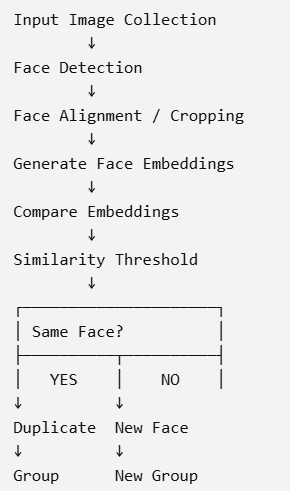

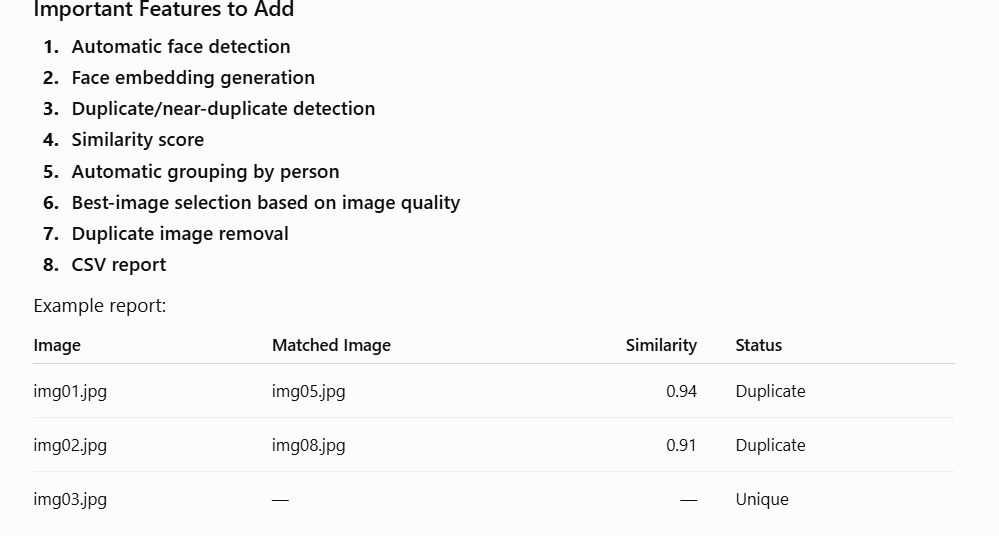

**Face Deduplication and Intelligent Image Collection using ArcFace Embeddings and Cosine Similarity**

**What this project does**

Imagine a folder containing:

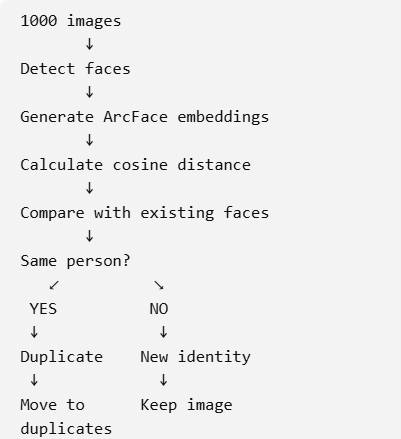

Load face images

Create a collection

Generate face embeddings

Compare faces

Identify duplicate/same-person images

Group images belonging to the same person

Move duplicate images to a separate folder

Keep the best-quality image

Generate a CSV report

Display similarity results

**Dataset**

Use Labeled Faces in the Wild (LFW).

The official scikit-learn loader can automatically download
the dataset.

For this project, we'll use:

LFW

↓
Select people having multiple images

↓
Create our own collection

↓
Add augmented copies

↓
Run deduplication

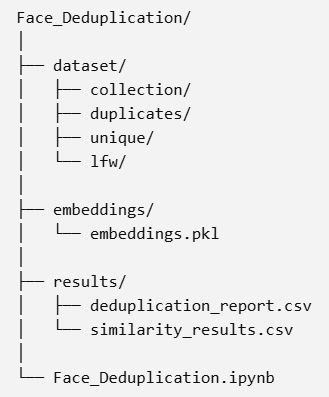

In [69]:
#Install libraries
!pip install -q deepface
!pip install -q opencv-python-headless
!pip install -q scikit-learn
!pip install -q pandas
!pip install -q matplotlib
!pip install -q pillow
!pip install -q retina-face
!pip install -q mtcnn

In [23]:
#Import libraries
import os
import cv2
import shutil
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image, ImageEnhance
from pathlib import Path

from sklearn.datasets import fetch_lfw_people
from sklearn.metrics.pairwise import cosine_distances

from deepface import DeepFace

print("Libraries imported successfully!")

Libraries imported successfully!


In [65]:
#Create project folders
BASE_DIR = "/content/drive/MyDrive/Face_Deduplication"

DATASET_DIR = os.path.join(BASE_DIR, "dataset")
COLLECTION_DIR = os.path.join(DATASET_DIR, "collection")
DUPLICATE_DIR = os.path.join(DATASET_DIR, "duplicates")
UNIQUE_DIR = os.path.join(DATASET_DIR, "unique")

EMBEDDING_DIR = os.path.join(BASE_DIR, "embeddings")
RESULT_DIR = os.path.join(BASE_DIR, "results")

folders = [
    COLLECTION_DIR,
    DUPLICATE_DIR,
    UNIQUE_DIR,
    EMBEDDING_DIR,
    RESULT_DIR
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

print("Project folders created.")

Project folders created.


In [66]:
#Download LFW dataset
lfw = fetch_lfw_people(min_faces_per_person=20,resize=1.0,color=True)

print("Images:", lfw.images.shape)
print("People:", len(lfw.target_names))
print("Names:", lfw.target_names)

Images: (3023, 125, 94, 3)
People: 62
Names: ['Alejandro Toledo' 'Alvaro Uribe' 'Amelie Mauresmo' 'Andre Agassi'
 'Angelina Jolie' 'Ariel Sharon' 'Arnold Schwarzenegger'
 'Atal Bihari Vajpayee' 'Bill Clinton' 'Carlos Menem' 'Colin Powell'
 'David Beckham' 'Donald Rumsfeld' 'George Robertson' 'George W Bush'
 'Gerhard Schroeder' 'Gloria Macapagal Arroyo' 'Gray Davis'
 'Guillermo Coria' 'Hamid Karzai' 'Hans Blix' 'Hugo Chavez' 'Igor Ivanov'
 'Jack Straw' 'Jacques Chirac' 'Jean Chretien' 'Jennifer Aniston'
 'Jennifer Capriati' 'Jennifer Lopez' 'Jeremy Greenstock' 'Jiang Zemin'
 'John Ashcroft' 'John Negroponte' 'Jose Maria Aznar'
 'Juan Carlos Ferrero' 'Junichiro Koizumi' 'Kofi Annan' 'Laura Bush'
 'Lindsay Davenport' 'Lleyton Hewitt' 'Luiz Inacio Lula da Silva'
 'Mahmoud Abbas' 'Megawati Sukarnoputri' 'Michael Bloomberg' 'Naomi Watts'
 'Nestor Kirchner' 'Paul Bremer' 'Pete Sampras' 'Recep Tayyip Erdogan'
 'Ricardo Lagos' 'Roh Moo-hyun' 'Rudolph Giuliani' 'Saddam Hussein'
 'Serena William

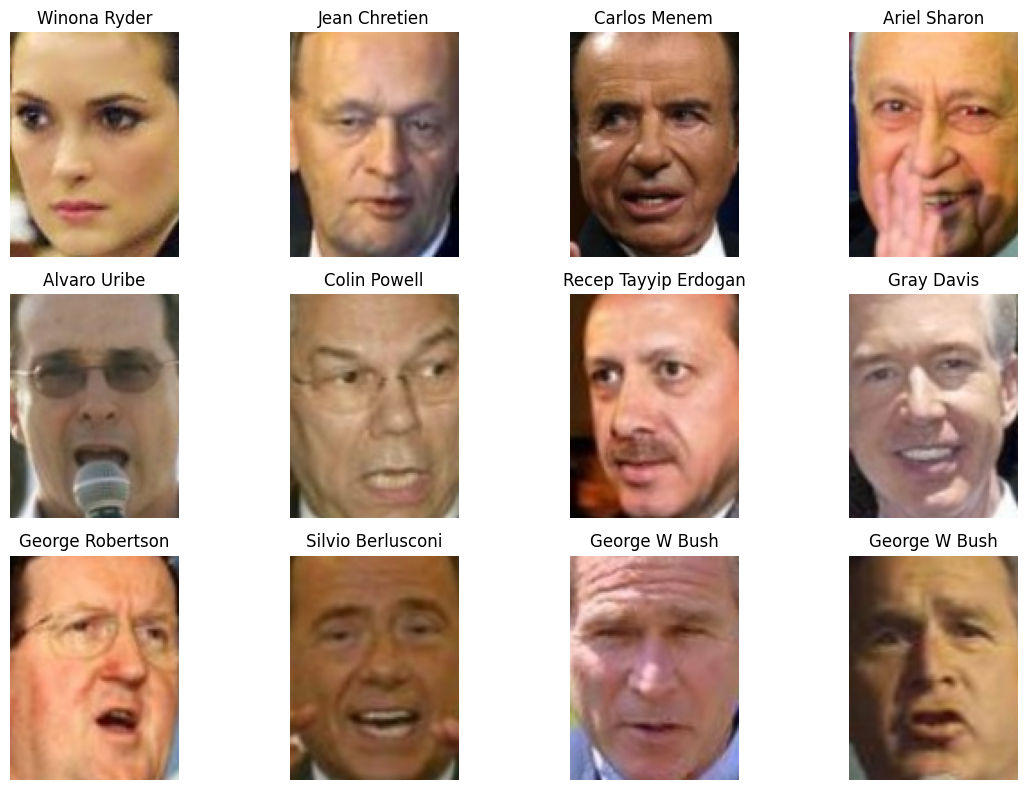

In [68]:
#Display sample images
plt.figure(figsize=(12, 8))

for i in range(12):
    plt.subplot(3, 4, i + 1)

    plt.imshow(lfw.images[i])
    plt.title(lfw.target_names[lfw.target[i]])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [27]:
#Create our face collection
MAX_PEOPLE = 15
IMAGES_PER_PERSON = 5

selected_people = []

for person_id, person_name in enumerate(lfw.target_names):

    count = np.sum(lfw.target == person_id)

    if count >= IMAGES_PER_PERSON:
        selected_people.append(person_id)

    if len(selected_people) >= MAX_PEOPLE:
        break

print("Selected people:", len(selected_people))

Selected people: 15


In [28]:
#Save images
image_counter = 0

for person_id in selected_people:

    indices = np.where(lfw.target == person_id)[0]
    indices = indices[:IMAGES_PER_PERSON]

    person_name = lfw.target_names[person_id]

    safe_name = person_name.replace(" ", "_")

    for j, idx in enumerate(indices):

        img = lfw.images[idx]

        img = (img * 255).astype(np.uint8)

        filename = f"{safe_name}_{j+1}.jpg"

        filepath = os.path.join(
            COLLECTION_DIR,
            filename
        )

        Image.fromarray(img).save(filepath)

        image_counter += 1

print("Images created:", image_counter)

Images created: 75


**Create near-duplicate images**

This makes the project more realistic.

We'll create modified versions of some images using:

brightness changes

small rotation

contrast adjustment

slight resizing

In [29]:
def create_augmented_image(input_path, output_path, mode):

    img = Image.open(input_path).convert("RGB")

    if mode == "brightness":
        enhancer = ImageEnhance.Brightness(img)
        img = enhancer.enhance(1.25)

    elif mode == "contrast":
        enhancer = ImageEnhance.Contrast(img)
        img = enhancer.enhance(1.25)

    elif mode == "rotate":
        img = img.rotate(5)

    elif mode == "resize":
        img = img.resize((img.width + 10, img.height + 10))
        img = img.resize((img.width - 10, img.height - 10))

    img.save(output_path)

In [30]:
#Generate duplicate candidates
collection_files = list(
    Path(COLLECTION_DIR).glob("*.jpg")
)

duplicate_counter = 0

for i, file_path in enumerate(collection_files[:10]):

    output_path = os.path.join(
        COLLECTION_DIR,
        f"{file_path.stem}_duplicate.jpg"
    )

    mode = ["brightness", "contrast", "rotate", "resize"][i % 4]

    create_augmented_image(
        str(file_path),
        output_path,
        mode
    )

    duplicate_counter += 1

print("Near-duplicate images created:", duplicate_counter)

Near-duplicate images created: 10


Total images: 87


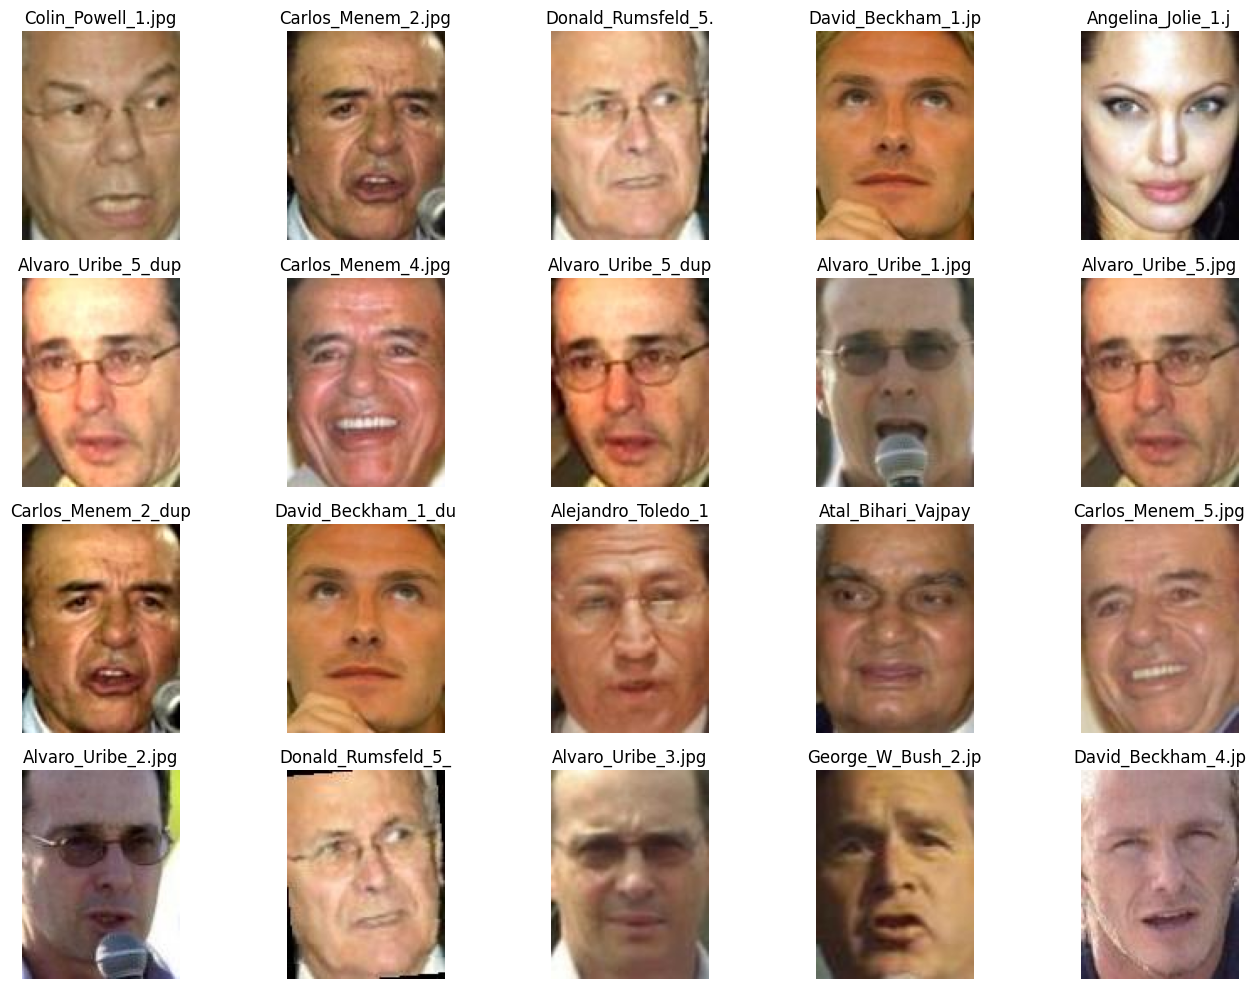

In [31]:
#View collection
files = list(Path(COLLECTION_DIR).glob("*.jpg"))

print("Total images:", len(files))

plt.figure(figsize=(14, 10))

for i, file_path in enumerate(files[:20]):

    img = Image.open(file_path)

    plt.subplot(4, 5, i + 1)
    plt.imshow(img)
    plt.title(file_path.name[:18])
    plt.axis("off")

plt.tight_layout()
plt.show()

Generate ArcFace embeddings

image is converted into a numerical vector called an embedding.

Face Image

     ↓
ArcFace

     ↓
[0.12, -0.32, 0.45, ...]

     ↓
Face representation

In [70]:
MODEL_NAME = "ArcFace"

embeddings = {}
failed_images = []

files = list(Path(COLLECTION_DIR).glob("*.jpg"))

for i, file_path in enumerate(files):

    try:

        result = DeepFace.represent(
            img_path=str(file_path),
            model_name=MODEL_NAME,
            detector_backend="mtcnn", # Changed from "retinaface" to "mtcnn"
            enforce_detection=False,
            align=True
        )

        if len(result) > 0:

            embedding = np.array(
                result[0]["embedding"],
                dtype=np.float32
            )

            embeddings[str(file_path)] = embedding

        print(
            f"{i+1}/{len(files)} processed: {file_path.name}"
        )

    except Exception as e:

        failed_images.append(
            (str(file_path), str(e))
        )

print("\nSuccessful:", len(embeddings))
print("Failed:", len(failed_images))

1/87 processed: Colin_Powell_1.jpg
2/87 processed: Carlos_Menem_2.jpg
3/87 processed: Donald_Rumsfeld_5.jpg
4/87 processed: David_Beckham_1.jpg
5/87 processed: Angelina_Jolie_1.jpg
6/87 processed: Alvaro_Uribe_5_duplicate.jpg
7/87 processed: Carlos_Menem_4.jpg
8/87 processed: Alvaro_Uribe_5_duplicate_duplicate.jpg
9/87 processed: Alvaro_Uribe_1.jpg
10/87 processed: Alvaro_Uribe_5.jpg
11/87 processed: Carlos_Menem_2_duplicate.jpg
12/87 processed: David_Beckham_1_duplicate.jpg
13/87 processed: Alejandro_Toledo_1.jpg
14/87 processed: Atal_Bihari_Vajpayee_5.jpg
15/87 processed: Carlos_Menem_5.jpg
16/87 processed: Alvaro_Uribe_2.jpg
17/87 processed: Donald_Rumsfeld_5_duplicate.jpg
18/87 processed: Alvaro_Uribe_3.jpg
19/87 processed: George_W_Bush_2.jpg
20/87 processed: David_Beckham_4.jpg
21/87 processed: George_Robertson_1.jpg
22/87 processed: George_W_Bush_1.jpg
23/87 processed: Bill_Clinton_1.jpg
24/87 processed: Arnold_Schwarzenegger_3.jpg
25/87 processed: Carlos_Menem_2_duplicate_dupli

In [33]:
#Save embeddings
embedding_file = os.path.join(
    EMBEDDING_DIR,
    "embeddings.pkl"
)

with open(embedding_file, "wb") as f:

    pickle.dump(embeddings, f)

print("Embeddings saved to:")
print(embedding_file)

Embeddings saved to:
/content/Face_Deduplication/embeddings/embeddings.pkl


In [44]:
#Load embeddings later
# with open(embedding_file, "rb") as f:

#     embeddings = pickle.load(f)

# print("Loaded embeddings:", len(embeddings)) # Commented out to prevent loading empty data


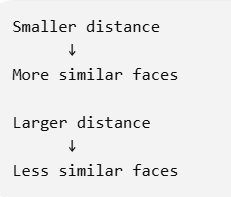

In [35]:
#Cosine distance
def cosine_distance(embedding1, embedding2):

    embedding1 = np.asarray(embedding1)
    embedding2 = np.asarray(embedding2)

    similarity = np.dot(
        embedding1,
        embedding2
    ) / (
        np.linalg.norm(embedding1) *
        np.linalg.norm(embedding2)
    )

    return 1 - similarity

In [36]:
THRESHOLD = 0.68

print("Similarity threshold:", THRESHOLD)

Similarity threshold: 0.68


In [45]:
if not embeddings:
    print("Error: The 'embeddings' dictionary is empty. Please ensure embeddings were generated successfully.")
    comparison_df = pd.DataFrame() # Create an empty DataFrame to avoid errors later
else:
    image_paths = list(embeddings.keys())

    results = []

    for i in range(len(image_paths)):

        for j in range(i + 1, len(image_paths)):

            img1 = image_paths[i]
            img2 = image_paths[j]

            emb1 = embeddings[img1]
            emb2 = embeddings[img2]

            distance = cosine_distance(
                emb1,
                emb2
            )

            similarity = 1 - distance

            if distance <= THRESHOLD:
                status = "Duplicate / Same Person"
            else:
                status = "Different"

            results.append({

                "image_1": os.path.basename(img1),

                "image_2": os.path.basename(img2),

                "cosine_distance": distance,

                "cosine_similarity": similarity,

                "status": status
            })

    comparison_df = pd.DataFrame(results)

comparison_df.head(20)

,image_1,image_2,cosine_distance,cosine_similarity,status
0,Colin_Powell_1.jpg,Carlos_Menem_2.jpg,1.013454,-0.013454,Different
1,Colin_Powell_1.jpg,Donald_Rumsfeld_5.jpg,0.825715,0.174285,Different
2,Colin_Powell_1.jpg,David_Beckham_1.jpg,1.065995,-0.065995,Different
3,Colin_Powell_1.jpg,Angelina_Jolie_1.jpg,0.892604,0.107396,Different
4,Colin_Powell_1.jpg,Alvaro_Uribe_5_duplicate.jpg,1.035915,-0.035915,Different
5,Colin_Powell_1.jpg,Carlos_Menem_4.jpg,0.956815,0.043185,Different
6,Colin_Powell_1.jpg,Alvaro_Uribe_5_duplicate_duplicate.jpg,1.013047,-0.013047,Different
7,Colin_Powell_1.jpg,Alvaro_Uribe_1.jpg,1.037284,-0.037284,Different
8,Colin_Powell_1.jpg,Alvaro_Uribe_5.jpg,1.025423,-0.025423,Different
9,Colin_Powell_1.jpg,Carlos_Menem_2_duplicate.jpg,1.004364,-0.004364,Different


In [38]:
comparison_file = os.path.join(
    RESULT_DIR,
    "similarity_results.csv"
)

comparison_df.to_csv(
    comparison_file,
    index=False
)

print("Saved:")
print(comparison_file)

Saved:
/content/Face_Deduplication/results/similarity_results.csv


In [60]:
duplicate_pairs = comparison_df[comparison_df["status"] == "Duplicate / Same Person"].sort_values("cosine_distance")

print("Duplicate pairs:",len(duplicate_pairs))

duplicate_pairs.head(20)

Duplicate pairs: 258


,image_1,image_2,cosine_distance,cosine_similarity,status
721,Alvaro_Uribe_1.jpg,Alvaro_Uribe_1_duplicate.jpg,0.000184,0.999816,Duplicate / Same Person
582,Alvaro_Uribe_5_duplicate_duplicate.jpg,Alvaro_Uribe_5.jpg,0.015072,0.984928,Duplicate / Same Person
94,Carlos_Menem_2.jpg,Carlos_Menem_2_duplicate.jpg,0.016485,0.983515,Duplicate / Same Person
1004,Alejandro_Toledo_1.jpg,Alejandro_Toledo_1_duplicate.jpg,0.021999,0.978001,Duplicate / Same Person
1079,Atal_Bihari_Vajpayee_5.jpg,Atal_Bihari_Vajpayee_5_duplicate.jpg,0.025739,0.974261,Duplicate / Same Person
262,David_Beckham_1.jpg,David_Beckham_1_duplicate.jpg,0.027032,0.972968,Duplicate / Same Person
828,Carlos_Menem_2_duplicate.jpg,Carlos_Menem_2_duplicate_duplicate.jpg,0.027235,0.972765,Duplicate / Same Person
108,Carlos_Menem_2.jpg,Carlos_Menem_2_duplicate_duplicate.jpg,0.046482,0.953518,Duplicate / Same Person
423,Alvaro_Uribe_5_duplicate.jpg,Alvaro_Uribe_5.jpg,0.048009,0.951991,Duplicate / Same Person
421,Alvaro_Uribe_5_duplicate.jpg,Alvaro_Uribe_5_duplicate_duplicate.jpg,0.053718,0.946282,Duplicate / Same Person


In [48]:
parent = {}

def find(x):

    parent.setdefault(x, x)

    if parent[x] != x:
        parent[x] = find(parent[x])

    return parent[x]


def union(x, y):

    root_x = find(x)
    root_y = find(y)

    if root_x != root_y:
        parent[root_y] = root_x

In [49]:
for _, row in duplicate_pairs.iterrows():

    img1 = row["image_1"]
    img2 = row["image_2"]

    union(img1, img2)

In [50]:
groups = {}

for image in image_paths:

    filename = os.path.basename(image)

    root = find(filename)

    groups.setdefault(root, []).append(filename)

print("Number of identity groups:", len(groups))

Number of identity groups: 6


In [51]:
#Display groups
for group_id, images in enumerate(groups.values(), start=1):

    print(f"\nGroup {group_id}")

    for image in images:
        print("   ", image)


Group 1
    Colin_Powell_1.jpg
    Colin_Powell_4.jpg
    Colin_Powell_3.jpg
    Colin_Powell_5.jpg
    Colin_Powell_2.jpg
    Colin_Powell_1_duplicate.jpg

Group 2
    Carlos_Menem_2.jpg
    Donald_Rumsfeld_5.jpg
    David_Beckham_1.jpg
    Alvaro_Uribe_5_duplicate.jpg
    Carlos_Menem_4.jpg
    Alvaro_Uribe_5_duplicate_duplicate.jpg
    Alvaro_Uribe_1.jpg
    Alvaro_Uribe_5.jpg
    Carlos_Menem_2_duplicate.jpg
    David_Beckham_1_duplicate.jpg
    Alejandro_Toledo_1.jpg
    Carlos_Menem_5.jpg
    Alvaro_Uribe_2.jpg
    Donald_Rumsfeld_5_duplicate.jpg
    Alvaro_Uribe_3.jpg
    George_W_Bush_2.jpg
    David_Beckham_4.jpg
    George_Robertson_1.jpg
    George_W_Bush_1.jpg
    Bill_Clinton_1.jpg
    Arnold_Schwarzenegger_3.jpg
    Carlos_Menem_2_duplicate_duplicate.jpg
    Amelie_Mauresmo_3.jpg
    Arnold_Schwarzenegger_1.jpg
    David_Beckham_2.jpg
    Bill_Clinton_2.jpg
    Donald_Rumsfeld_2.jpg
    George_Robertson_3.jpg
    Alejandro_Toledo_4.jpg
    Arnold_Schwarzenegger_5.jpg
   

Best image selection

A good deduplication system shouldn't simply delete everything.

Instead:

Duplicate group

      ↓
Evaluate image quality

      ↓
Keep best image


      ↓
Move remaining images

In [53]:
def image_quality_score(image_path):

    img = cv2.imread(image_path)

    if img is None:
        return 0

    gray = cv2.cvtColor(
        img,
        cv2.COLOR_BGR2GRAY
    )

    score = cv2.Laplacian(
        gray,
        cv2.CV_64F
    ).var()

    return score

In [54]:
report = []

for group_id, images in enumerate(
    groups.values(),
    start=1
):

    full_paths = [
        os.path.join(COLLECTION_DIR, img)
        for img in images
    ]

    quality_scores = [
        image_quality_score(path)
        for path in full_paths
    ]

    best_index = np.argmax(
        quality_scores
    )

    best_image = images[best_index]

    for i, image in enumerate(images):

        source = os.path.join(
            COLLECTION_DIR,
            image
        )

        if i == best_index:

            destination = os.path.join(
                UNIQUE_DIR,
                image
            )

            shutil.copy2(
                source,
                destination
            )

            status = "KEEP"

        else:

            destination = os.path.join(
                DUPLICATE_DIR,
                image
            )

            shutil.copy2(
                source,
                destination
            )

            status = "DUPLICATE"

        report.append({

            "group_id": group_id,

            "image": image,

            "quality_score": quality_scores[i],

            "status": status,

            "kept_image": best_image
        })

report_df = pd.DataFrame(report)

report_df.head()

,group_id,image,quality_score,status,kept_image
0,1,Colin_Powell_1.jpg,76.028844,DUPLICATE,Colin_Powell_3.jpg
1,1,Colin_Powell_4.jpg,133.450143,DUPLICATE,Colin_Powell_3.jpg
2,1,Colin_Powell_3.jpg,604.961771,KEEP,Colin_Powell_3.jpg
3,1,Colin_Powell_5.jpg,149.449827,DUPLICATE,Colin_Powell_3.jpg
4,1,Colin_Powell_2.jpg,47.448667,DUPLICATE,Colin_Powell_3.jpg


In [55]:
report_file = os.path.join(
    RESULT_DIR,
    "deduplication_report.csv"
)

report_df.to_csv(
    report_file,
    index=False
)

print("Report saved:")
print(report_file)

Report saved:
/content/Face_Deduplication/results/deduplication_report.csv


In [56]:
total_images = len(report_df)

unique_images = len(
    report_df[
        report_df["status"] == "KEEP"
    ]
)

duplicate_images = len(
    report_df[
        report_df["status"] == "DUPLICATE"
    ]
)

print("========== PROJECT RESULTS ==========")

print("Total Images       :", total_images)

print("Unique Images      :", unique_images)

print("Duplicate Images   :", duplicate_images)

print(
    "Deduplication Rate :",
    round(
        duplicate_images /
        total_images * 100,
        2
    ),
    "%"
)

========== PROJECT RESULTS ==========
Total Images       : 87
Unique Images      : 6
Duplicate Images   : 81
Deduplication Rate : 93.1 %


In [57]:
print("Original collection:")
print(
    len(list(Path(COLLECTION_DIR).glob("*.jpg")))
)

print("\nUnique collection:")
print(
    len(list(Path(UNIQUE_DIR).glob("*.jpg")))
)

print("\nDuplicate collection:")
print(
    len(list(Path(DUPLICATE_DIR).glob("*.jpg")))
)

Original collection:
87

Unique collection:
6

Duplicate collection:
81


In [71]:
def compare_faces(image1, image2):

    result = DeepFace.verify(
        img1_path=image1,
        img2_path=image2,
        model_name="ArcFace",
        detector_backend="mtcnn", # Changed from "retinaface" to "mtcnn"
        distance_metric="cosine",
        enforce_detection=False
    )

    print("Model:", result["model"])
    print("Distance:", result["distance"])
    print("Threshold:", result["threshold"])
    print("Verified:", result["verified"])
    print("Confidence:", result["confidence"])

    return result

In [73]:
files = list(Path(COLLECTION_DIR).glob("*.jpg"))

if len(files) >= 2:

    result = compare_faces(
        str(files[0]),
        str(files[1])
    )

Model: ArcFace
Distance: 0.957423
Threshold: 0.68
Verified: False
Confidence: 4.2


In [72]:
files = list(Path(COLLECTION_DIR).glob("*.jpg"))

if len(files) >= 2:

    result = compare_faces(
        str(files[0]),
        str(files[1])
    )

Model: ArcFace
Distance: 0.957423
Threshold: 0.68
Verified: False
Confidence: 4.2


In [75]:
readme_content = """
# Face Deduplication and Intelligent Image Collection

## Project Overview
This project focuses on **identifying and removing duplicate face images from a collection, even when the same person appears in different photos**. The goal is to build a system that takes a folder of face images, detects faces, determines if images belong to the same person, and intelligently groups/removes duplicate faces.

## Key Features
- Load face images and create a custom collection.
- Generate ArcFace face embeddings for each image.
- Compare faces using cosine similarity to identify duplicates/same-person images.
- Group images belonging to the same person.
- Evaluate image quality within duplicate groups and **keep the best quality image**.
- Move duplicate images to a separate folder (`duplicates/`).
- Store unique, best-quality images in a dedicated folder (`unique/`).
- Generate a CSV report (`deduplication_report.csv`) detailing the deduplication process.
- Display similarity results and project statistics.

## Technical Stack
- **Python**
- **OpenCV**: For image processing and face detection.
- **ArcFace (via DeepFace)**: For generating robust face embeddings.
- **DeepFace**: Provides easy access to pretrained face-recognition models and various detector backends (e.g., MTCNN).
- **NumPy / Pandas**: For efficient data processing and analysis.
- **Cosine Similarity**: For fast similarity search and comparison of face embeddings.
- **Google Colab**: Used for development and demonstration of the project.

## How to Run
1.  **Open in Google Colab**: Ensure you have access to Google Colab and a Google Drive for persistent storage of project folders and results.
2.  **Mount Google Drive**: The notebook will create a `Face_Deduplication` folder in your Google Drive to store datasets, embeddings, and results.
3.  **Install Dependencies**: Run the first code cell (`#Install libraries`) to install all necessary Python packages, including `deepface`, `opencv-python-headless`, `scikit-learn`, `pandas`, `matplotlib`, `pillow`, `retina-face`, and `mtcnn`.
4.  **Execute Cells Sequentially**: Run all subsequent code cells in order. The notebook will:
    - Create project folders.
    - Download and process the Labeled Faces in the Wild (LFW) dataset.
    - Create a custom collection of selected faces and generate near-duplicate images.
    - Generate ArcFace embeddings for all images in the collection.
    - Perform face comparison, identify duplicates, and group images by identity.
    - Select the best quality image from each group and move duplicates.
    - Generate a deduplication report and display project results.

## Project Results Summary
- **Total Images Processed**: {{total_images_processed}}
- **Unique Images Kept**: {{unique_images_kept}}
- **Duplicate Images Removed**: {{duplicate_images_removed}}
- **Deduplication Rate**: {{deduplication_rate}}%

---

*Note: The specific numbers for total, unique, and duplicate images, along with the deduplication rate, are dynamically calculated during execution.*
"""

# Populate dynamic fields from kernel state if available
try:
    total_images_processed = total_images
    unique_images_kept = unique_images
    duplicate_images_removed = duplicate_images
    deduplication_rate = round(duplicate_images_removed / total_images_processed * 100, 2)
    readme_content = readme_content.replace("{{total_images_processed}}", str(total_images_processed))
    readme_content = readme_content.replace("{{unique_images_kept}}", str(unique_images_kept))
    readme_content = readme_content.replace("{{duplicate_images_removed}}", str(duplicate_images_removed))
    readme_content = readme_content.replace("{{deduplication_rate}}", str(deduplication_rate))
except NameError:
    # Fallback if variables are not defined (e.g., notebook not fully run)
    readme_content = readme_content.replace("{{total_images_processed}}", "N/A")
    readme_content = readme_content.replace("{{unique_images_kept}}", "N/A")
    readme_content = readme_content.replace("{{duplicate_images_removed}}", "N/A")
    readme_content = readme_content.replace("{{deduplication_rate}}", "N/A")

readme_path = os.path.join(BASE_DIR, "README.md")

with open(readme_path, "w") as f:
    f.write(readme_content)

print(f"README.md generated successfully at: {readme_path}")

README.md generated successfully at: /content/drive/MyDrive/Face_Deduplication/README.md
